In [6]:
import pickle
import pandas as pd
import joblib

In [7]:
model_prefix  = '../2_model_development/'
data_prefix = '../0_data/processed_data/'
non_feature_cols = ['SMILES', 'MP', 'Type', 'Ro5']
model_types = ['RF', 'XGB', 'LGB']

In [8]:
for model_type in model_types:
    model_path = f'{model_prefix}best_model_{model_type}.joblib'
    joblib.load(model_path)


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

def model_evaluation(data_test, model):

    non_feature_cols = ['SMILES', 'MP', 'Type', 'Ro5']

    result = data_test.copy()
    X = result.drop(columns=non_feature_cols)
    result['MP_pred'] = model.predict(X)

    # ── Compute metrics for each subset ───────────────────────────────
    subsets = {
        'Ro5 = 1':  result[result['Ro5'] == 1],
        'Ro5 = 0':  result[result['Ro5'] == 0],
        'Overall':  result,
    }

    labels, rmses, r2s = [], [], []
    for label, subset in subsets.items():
        y_true = subset['MP'].values
        y_pred = subset['MP_pred'].values
        rmses.append(np.sqrt(mean_squared_error(y_true, y_pred)))
        r2s.append(r2_score(y_true, y_pred))
        labels.append(label)

    colors = ['#4C72B0', '#DD8452', '#55A868']

    # ── Figure 1: RMSE ────────────────────────────────────────────────
    fig1, ax1 = plt.subplots(figsize=(6, 4))
    bars1 = ax1.bar(labels, rmses, color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars1, rmses):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=11)
    ax1.set_ylabel('RMSE (°C)', fontsize=12)
    ax1.set_title('Model RMSE by Ro5 Group', fontsize=13)
    ax1.set_ylim(0, max(rmses) * 1.2)
    ax1.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    # ── Figure 2: R² ──────────────────────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(6, 4))
    bars2 = ax2.bar(labels, r2s, color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars2, r2s):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=11)
    ax2.set_ylabel('R²', fontsize=12)
    ax2.set_title('Model R² by Ro5 Group', fontsize=13)
    ax2.set_ylim(0, 1.1)
    ax2.axhline(y=1, color='grey', linestyle='--', linewidth=0.8)
    ax2.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    return result

Evaluating model: RF


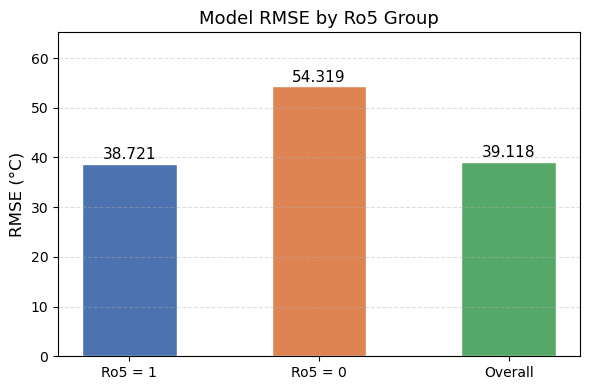

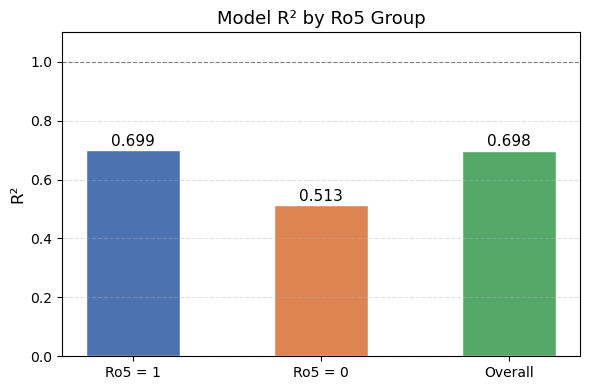

Evaluating model: XGB


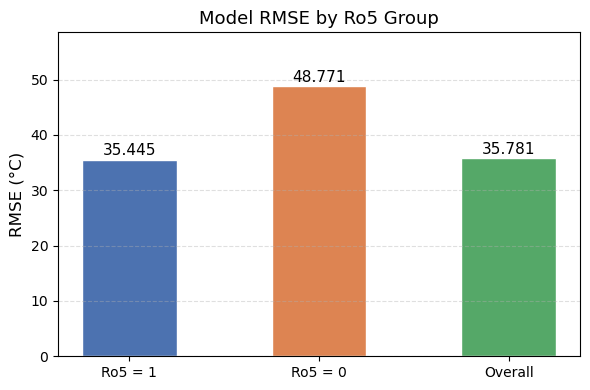

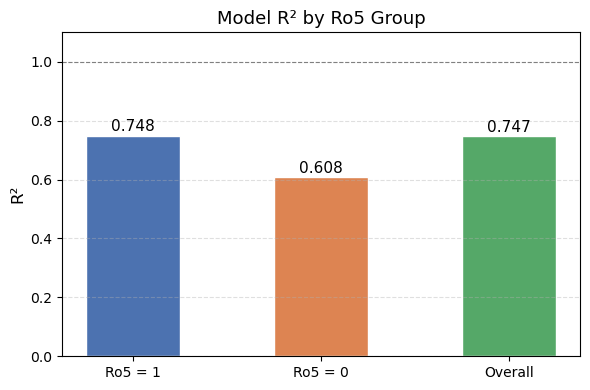

Evaluating model: LGB


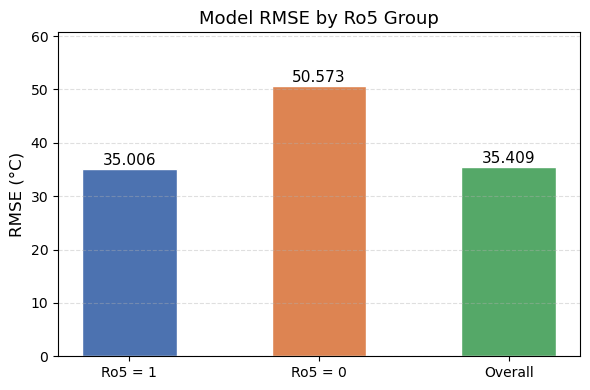

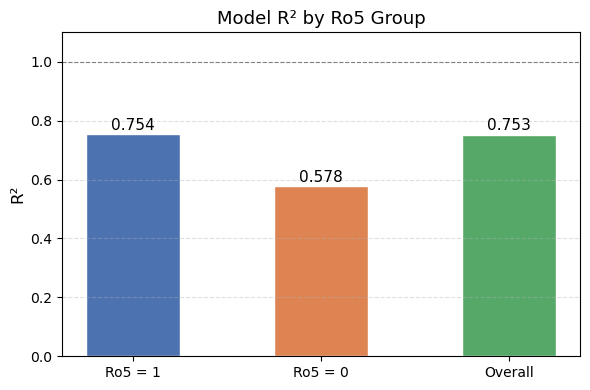

In [11]:
for model_name in model_types:

    print(f"Evaluating model: {model_name}")
    model_path = f'{model_prefix}best_model_{model_name}.joblib'
    model = joblib.load(model_path)
    data = pd.read_parquet(data_prefix + f"data_with_selected_features_{model_name}_scaled.parquet")
    data_test = data[data['Type']=='Test']
    mp_pred = model_evaluation(data_test, model)

    mp_pred.to_csv(f"model_evaluation_results_{model_name}.csv", index=False)